Bu projede, Transfermarkt veri seti kullanılarak futbolcuların piyasa değerlerinin tahmin edilmesi amaçlanmıştır. Veri setinde futbolcuların pozisyonları, boyları, kullandıkları ayak, milli takım istatistikleri, oynadıkları kulüpler ve performans verileri gibi birçok değişken yer almaktadır.

In [1]:
import pandas as pd

players = pd.read_csv("players.csv")

players.head()

,player_id,first_name,last_name,name,last_season,current_club_id,player_code,country_of_birth,city_of_birth,country_of_citizenship,...,agent_name,image_url,international_caps,international_goals,current_national_team_id,url,current_club_domestic_competition_id,current_club_name,market_value_in_eur,highest_market_value_in_eur
0,10,Miroslav,Klose,Miroslav Klose,2015,398,miroslav-klose,Poland,Opole,Germany,...,ASBW Sport Marketing,https://img.a.transfermarkt.technology/portrai...,NaN,NaN,NaN,https://www.transfermarkt.co.uk/miroslav-klose...,IT1,Società Sportiva Lazio S.p.A.,1000000.0,30000000.0
1,26,Roman,Weidenfeller,Roman Weidenfeller,2017,16,roman-weidenfeller,Germany,Diez,Germany,...,Neubauer 13 GmbH,https://img.a.transfermarkt.technology/portrai...,NaN,NaN,NaN,https://www.transfermarkt.co.uk/roman-weidenfe...,L1,Borussia Dortmund,750000.0,8000000.0
2,65,Dimitar,Berbatov,Dimitar Berbatov,2015,1091,dimitar-berbatov,Bulgaria,Blagoevgrad,Bulgaria,...,CSKA-AS-23 Ltd.,https://img.a.transfermarkt.technology/portrai...,NaN,NaN,NaN,https://www.transfermarkt.co.uk/dimitar-berbat...,GR1,Panthessalonikios Athlitikos Omilos Konstantin...,1000000.0,34500000.0
3,77,NaN,Lúcio,Lúcio,2012,506,lucio,Brazil,Brasília,Brazil,...,NaN,https://img.a.transfermarkt.technology/portrai...,NaN,NaN,NaN,https://www.transfermarkt.co.uk/lucio/profil/s...,IT1,Juventus Football Club,200000.0,24500000.0
4,80,Tom,Starke,Tom Starke,2017,27,tom-starke,East Germany (GDR),Freital,Germany,...,IFM,https://img.a.transfermarkt.technology/portrai...,NaN,NaN,NaN,https://www.transfermarkt.co.uk/tom-starke/pro...,L1,FC Bayern München,100000.0,3000000.0


In [2]:
players.columns

Index(['player_id', 'first_name', 'last_name', 'name', 'last_season',
       'current_club_id', 'player_code', 'country_of_birth', 'city_of_birth',
       'country_of_citizenship', 'date_of_birth', 'sub_position', 'position',
       'foot', 'height_in_cm', 'contract_expiration_date', 'agent_name',
       'image_url', 'international_caps', 'international_goals',
       'current_national_team_id', 'url',
       'current_club_domestic_competition_id', 'current_club_name',
       'market_value_in_eur', 'highest_market_value_in_eur'],
      dtype='object')

In [3]:
players.shape

(47690, 26)

In [4]:
players.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47690 entries, 0 to 47689
Data columns (total 26 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   player_id                             47690 non-null  int64  
 1   first_name                            44598 non-null  object 
 2   last_name                             47690 non-null  object 
 3   name                                  47690 non-null  object 
 4   last_season                           47690 non-null  int64  
 5   current_club_id                       47690 non-null  int64  
 6   player_code                           47690 non-null  object 
 7   country_of_birth                      42525 non-null  object 
 8   city_of_birth                         42801 non-null  object 
 9   country_of_citizenship                47417 non-null  object 
 10  date_of_birth                         47641 non-null  object 
 11  sub_position   

In [5]:
valuations = pd.read_csv("player_valuations.csv")

valuations.head()

,player_id,date,market_value_in_eur,current_club_name,current_club_id,player_club_domestic_competition_id
0,405973,2000-01-20,150000,Unknown,3057,BE1
1,342216,2001-07-20,100000,Unknown,1241,SC1
2,3132,2003-12-09,400000,Dynamo Kyiv,126,TR1
3,6893,2003-12-15,900000,Galatasaray,984,GB1
4,10,2004-10-04,7000000,SV Werder Bremen,398,IT1


In [6]:
valuations.shape

(647626, 6)

In [7]:
valuations.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 647626 entries, 0 to 647625
Data columns (total 6 columns):
 #   Column                               Non-Null Count   Dtype 
---  ------                               --------------   ----- 
 0   player_id                            647626 non-null  int64 
 1   date                                 647626 non-null  object
 2   market_value_in_eur                  647626 non-null  int64 
 3   current_club_name                    647626 non-null  object
 4   current_club_id                      647626 non-null  int64 
 5   player_club_domestic_competition_id  556426 non-null  object
dtypes: int64(3), object(3)
memory usage: 29.6+ MB


In [8]:
# Oyuncu bilgileri ile piyasa değerlerini birleştiriyoruz.
df = players.merge(valuations, on="player_id", how="inner")

df.shape

(647626, 31)

In [9]:
df.columns

Index(['player_id', 'first_name', 'last_name', 'name', 'last_season',
       'current_club_id_x', 'player_code', 'country_of_birth', 'city_of_birth',
       'country_of_citizenship', 'date_of_birth', 'sub_position', 'position',
       'foot', 'height_in_cm', 'contract_expiration_date', 'agent_name',
       'image_url', 'international_caps', 'international_goals',
       'current_national_team_id', 'url',
       'current_club_domestic_competition_id', 'current_club_name_x',
       'market_value_in_eur_x', 'highest_market_value_in_eur', 'date',
       'market_value_in_eur_y', 'current_club_name_y', 'current_club_id_y',
       'player_club_domestic_competition_id'],
      dtype='object')

In [10]:
#Modelde kullanacağımız sütunları seçiyoruz.
kolonlar = [
    "height_in_cm",
    "international_caps",
    "international_goals",
    "position",
    "sub_position",
    "foot",
    "country_of_citizenship",
    "last_season",
    "current_club_name_x",
    "current_club_domestic_competition_id",
    "market_value_in_eur_y"
]

df_model = df[kolonlar]

df_model.shape

(647626, 11)

In [11]:
df_model["current_club_name_x"].nunique()

793

In [12]:
#En çok görülen 30 kulübü bırakıyoruz.
top_kulupler = (
    df_model["current_club_name_x"]
    .value_counts()
    .head(30)
    .index
)

In [13]:
#Diğer kulüpleri Other olarak birleştiriyoruz.
df_model["current_club_name_x"] = (
    df_model["current_club_name_x"]
    .fillna("Other")
    .apply(lambda x: x if x in top_kulupler else "Other")
)

C:\Users\mehmet.sefer.kaya\AppData\Local\Temp\ipykernel_20948\4227905238.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model["current_club_name_x"] = (


In [14]:
df_model.isnull().sum()

height_in_cm                             13886
international_caps                      389974
international_goals                     389974
position                                     0
sub_position                               880
foot                                     23846
country_of_citizenship                    3853
last_season                                  0
current_club_name_x                          0
current_club_domestic_competition_id     28242
market_value_in_eur_y                        0
dtype: int64

In [15]:
#Sayısal sütunları medyan ve sıfır ile dolduruyoruz.
df_model["height_in_cm"] = df_model["height_in_cm"].fillna(
    df_model["height_in_cm"].median()
)

df_model["international_caps"] = df_model["international_caps"].fillna(0)

df_model["international_goals"] = df_model["international_goals"].fillna(0)

C:\Users\mehmet.sefer.kaya\AppData\Local\Temp\ipykernel_20948\193934410.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model["height_in_cm"] = df_model["height_in_cm"].fillna(
C:\Users\mehmet.sefer.kaya\AppData\Local\Temp\ipykernel_20948\193934410.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model["international_caps"] = df_model["international_caps"].fillna(0)
C:\Users\mehmet.sefer.kaya\AppData\Local\Temp\ipykernel_20948\193934410.py:8: SettingWithCopyWarning: 
A value is trying to be set

In [16]:
# Kategorik sütunları mod ile dolduruyoruz.

df_model["sub_position"] = df_model["sub_position"].fillna(
    df_model["sub_position"].mode()[0]
)

df_model["foot"] = df_model["foot"].fillna(
    df_model["foot"].mode()[0]
)

df_model["country_of_citizenship"] = df_model["country_of_citizenship"].fillna(
    df_model["country_of_citizenship"].mode()[0]
)

df_model["current_club_domestic_competition_id"] = (
    df_model["current_club_domestic_competition_id"]
    .fillna(
        df_model["current_club_domestic_competition_id"].mode()[0]
    )
)

C:\Users\mehmet.sefer.kaya\AppData\Local\Temp\ipykernel_20948\2627515650.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model["sub_position"] = df_model["sub_position"].fillna(
C:\Users\mehmet.sefer.kaya\AppData\Local\Temp\ipykernel_20948\2627515650.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model["foot"] = df_model["foot"].fillna(
C:\Users\mehmet.sefer.kaya\AppData\Local\Temp\ipykernel_20948\2627515650.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from

In [17]:
df_model.isnull().sum()

height_in_cm                            0
international_caps                      0
international_goals                     0
position                                0
sub_position                            0
foot                                    0
country_of_citizenship                  0
last_season                             0
current_club_name_x                     0
current_club_domestic_competition_id    0
market_value_in_eur_y                   0
dtype: int64

In [18]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 647626 entries, 0 to 647625
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   height_in_cm                          647626 non-null  float64
 1   international_caps                    647626 non-null  float64
 2   international_goals                   647626 non-null  float64
 3   position                              647626 non-null  object 
 4   sub_position                          647626 non-null  object 
 5   foot                                  647626 non-null  object 
 6   country_of_citizenship                647626 non-null  object 
 7   last_season                           647626 non-null  int64  
 8   current_club_name_x                   647626 non-null  object 
 9   current_club_domestic_competition_id  647626 non-null  object 
 10  market_value_in_eur_y                 647626 non-null  int64  
dtype

In [19]:
# Kategorik değişkenleri sayısal hale dönüştürüyoruz.
df_model = pd.get_dummies(
    df_model,
    columns=[
        "position",
        "sub_position",
        "foot",
        "country_of_citizenship",
        "current_club_name_x",
        "current_club_domestic_competition_id"
    ],
    drop_first=True
)

In [20]:
df_model.shape

(647626, 278)

In [21]:
#Bağımlı ve bağımsız değişkenleri ayırıyoruz.
x = df_model.drop("market_value_in_eur_y", axis=1)

y = df_model["market_value_in_eur_y"]

In [22]:
#Eğitim ve test verilerini oluşturuyoruz.
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42)

In [23]:
#Linear Regression modelini kuruyoruz.
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(x_train, y_train)

lr_pred = lr.predict(x_test)

In [24]:
#Linear Regression sonuçlarını hesaplıyoruz.
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("MAE:", mean_absolute_error(y_test, lr_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, lr_pred)))
print("R2 Score:", r2_score(y_test, lr_pred))

MAE: 2521611.407489414
RMSE: 5721290.025434921
R2 Score: 0.23850964931996688


In [25]:
#Random Forest modelini kuruyoruz.
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=30,
    random_state=42,
    n_jobs=-1
)

rf.fit(x_train, y_train)

rf_pred = rf.predict(x_test)

In [26]:
print("MAE:", mean_absolute_error(y_test, rf_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("R2 Score:", r2_score(y_test, rf_pred))

MAE: 1442791.4861852638
RMSE: 4214984.650518644
R2 Score: 0.5866970816246125


In [28]:
# Başarı oranını artırmak için farklı bir data dosyasınıda çalışmaya ekliyoruz.
appearances = pd.read_csv("appearances.csv")
appearances.columns

Index(['appearance_id', 'game_id', 'player_id', 'player_club_id',
       'player_current_club_id', 'date', 'player_name', 'competition_id',
       'yellow_cards', 'red_cards', 'goals', 'assists', 'minutes_played'],
      dtype='object')

In [29]:
#Oyuncu bazında özet oluşturuyoruz.
performans = appearances.groupby("player_id").agg({
    "goals":"sum",
    "assists":"sum",
    "minutes_played":"sum",
    "yellow_cards":"sum",
    "red_cards":"sum"
}).reset_index()

performans.head()

,player_id,goals,assists,minutes_played,yellow_cards,red_cards
0,10,48,25,8808,19,0
1,26,0,0,13508,4,2
2,65,38,13,8788,11,1
3,77,0,0,307,0,0
4,80,0,0,1080,0,0


In [30]:
# Ana tabloya ekliyoruz.
df = df.merge(performans, on="player_id", how="left")

df.shape

(647626, 36)

In [32]:
# Model için gerekl sütunları alıyoruz.
kolonlar = [

    "height_in_cm",
    "international_caps",
    "international_goals",

    "goals",
    "assists",
    "minutes_played",
    "yellow_cards",
    "red_cards",

    "position",
    "sub_position",
    "foot",

    "current_club_name_y",
    "current_club_domestic_competition_id",

    "market_value_in_eur_y"
]

df_model = df[kolonlar]

In [33]:
df_model.isnull().sum()

height_in_cm                             13886
international_caps                      389974
international_goals                     389974
goals                                   136816
assists                                 136816
minutes_played                          136816
yellow_cards                            136816
red_cards                               136816
position                                     0
sub_position                               880
foot                                     23846
current_club_name_y                          0
current_club_domestic_competition_id     28242
market_value_in_eur_y                        0
dtype: int64

In [34]:
# Eksikleri dolduruyoruz.
sutunlar = [
    "goals",
    "assists",
    "minutes_played",
    "yellow_cards",
    "red_cards"
]

df[sutunlar] = df[sutunlar].fillna(0)

In [35]:
# Kalan eksik verileri tekrar dolduruyoruz.
df_model["height_in_cm"] = df_model["height_in_cm"].fillna(
    df_model["height_in_cm"].median()
)

df_model["international_caps"] = df_model["international_caps"].fillna(0)

df_model["international_goals"] = df_model["international_goals"].fillna(0)

df_model["foot"] = df_model["foot"].fillna(
    df_model["foot"].mode()[0]
)

df_model["sub_position"] = df_model["sub_position"].fillna(
    df_model["sub_position"].mode()[0]
)

df_model["current_club_name_y"] = df_model["current_club_name_y"].fillna(
    "Unknown"
)

df_model["current_club_domestic_competition_id"] = (
    df_model["current_club_domestic_competition_id"]
    .fillna("Unknown")
)

C:\Users\mehmet.sefer.kaya\AppData\Local\Temp\ipykernel_20948\2987475862.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model["height_in_cm"] = df_model["height_in_cm"].fillna(
C:\Users\mehmet.sefer.kaya\AppData\Local\Temp\ipykernel_20948\2987475862.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model["international_caps"] = df_model["international_caps"].fillna(0)
C:\Users\mehmet.sefer.kaya\AppData\Local\Temp\ipykernel_20948\2987475862.py:8: SettingWithCopyWarning: 
A value is trying to be 

In [36]:
# Kategorikleri dönüştürüyoruz.
df_model = pd.get_dummies(
    df_model,
    columns=[
        "position",
        "sub_position",
        "foot",
        "current_club_name_y",
        "current_club_domestic_competition_id"
    ],
    drop_first=True
)

In [37]:
df_model.shape

(647626, 8101)

In [43]:
# Sütun sayısı çok fazla olduğundan kulüp isimlerini çıkararak Model için gerekli sütunları tekrar oluşturuyoruz.
kolonlar = [

    "height_in_cm",
    "international_caps",
    "international_goals",

    "goals",
    "assists",
    "minutes_played",
    "yellow_cards",
    "red_cards",

    "position",
    "sub_position",
    "foot",

    "current_club_domestic_competition_id",

    "market_value_in_eur_y"
]

df_model = df[kolonlar]

In [44]:
df_model.isnull().sum()

height_in_cm                             13886
international_caps                      389974
international_goals                     389974
goals                                        0
assists                                      0
minutes_played                               0
yellow_cards                                 0
red_cards                                    0
position                                     0
sub_position                               880
foot                                     23846
current_club_domestic_competition_id     28242
market_value_in_eur_y                        0
dtype: int64

In [45]:
# Eksik verileri dolduruyoruz.
df_model["height_in_cm"] = df_model["height_in_cm"].fillna(
    df_model["height_in_cm"].median()
)

df_model["international_caps"] = df_model["international_caps"].fillna(0)

df_model["international_goals"] = df_model["international_goals"].fillna(0)

df_model["foot"] = df_model["foot"].fillna(
    df_model["foot"].mode()[0]
)

df_model["sub_position"] = df_model["sub_position"].fillna(
    df_model["sub_position"].mode()[0]
)

df_model["current_club_domestic_competition_id"] = (
    df_model["current_club_domestic_competition_id"]
    .fillna("Unknown")
)

C:\Users\mehmet.sefer.kaya\AppData\Local\Temp\ipykernel_20948\3598988048.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model["height_in_cm"] = df_model["height_in_cm"].fillna(
C:\Users\mehmet.sefer.kaya\AppData\Local\Temp\ipykernel_20948\3598988048.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model["international_caps"] = df_model["international_caps"].fillna(0)
C:\Users\mehmet.sefer.kaya\AppData\Local\Temp\ipykernel_20948\3598988048.py:8: SettingWithCopyWarning: 
A value is trying to be 

In [46]:
df_model.isnull().sum()

height_in_cm                            0
international_caps                      0
international_goals                     0
goals                                   0
assists                                 0
minutes_played                          0
yellow_cards                            0
red_cards                               0
position                                0
sub_position                            0
foot                                    0
current_club_domestic_competition_id    0
market_value_in_eur_y                   0
dtype: int64

In [47]:
df_model = pd.get_dummies(
    df_model,
    columns=[
        "position",
        "sub_position",
        "foot",
        "current_club_domestic_competition_id"
    ],
    drop_first=True
)

In [48]:
df_model.shape

(647626, 59)

In [50]:
x = df_model.drop("market_value_in_eur_y", axis=1)

y = df_model["market_value_in_eur_y"]

In [51]:
#Eğitim ve test verilerini oluşturuyoruz.
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42)

In [52]:
#Linear Regression modelini kuruyoruz.
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(x_train, y_train)

lr_pred = lr.predict(x_test)

In [53]:
#Linear Regression sonuçlarını hesaplıyoruz.
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("MAE:", mean_absolute_error(y_test, lr_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, lr_pred)))
print("R2 Score:", r2_score(y_test, lr_pred))

MAE: 2246319.275990319
RMSE: 5424139.152647351
R2 Score: 0.31555568257576616


In [54]:
#Random Forest modelini kuruyoruz.
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(x_train, y_train)

rf_pred = rf.predict(x_test)

In [55]:
print("MAE:", mean_absolute_error(y_test, rf_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("R2 Score:", r2_score(y_test, rf_pred))

MAE: 1428366.7192920898
RMSE: 4202011.970375095
R2 Score: 0.5892372548852124


In [56]:
df_model["market_value_in_eur_y"].describe()

count    6.476260e+05
mean     2.266253e+06
std      6.641203e+06
min      0.000000e+00
25%      2.000000e+05
50%      5.000000e+05
75%      1.500000e+06
max      2.000000e+08
Name: market_value_in_eur_y, dtype: float64

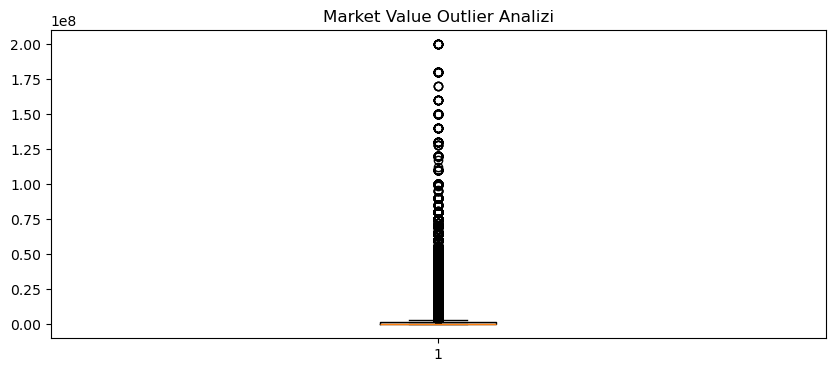

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.boxplot(df_model["market_value_in_eur_y"])
plt.title("Market Value Outlier Analizi")
plt.show()

In [58]:
# En değerli 20 oyuncu
df[
    ["name","market_value_in_eur_y"]
].sort_values(
    by="market_value_in_eur_y",
    ascending=False
).head(20)

,name,market_value_in_eur_y
426647,Kylian Mbappé,200000000
426648,Kylian Mbappé,200000000
426646,Kylian Mbappé,200000000
426663,Kylian Mbappé,200000000
627301,Lamine Yamal,200000000
478759,Erling Haaland,200000000
449520,Vinicius Junior,200000000
449521,Vinicius Junior,200000000
478756,Erling Haaland,200000000
627300,Lamine Yamal,200000000


In [59]:
# Aşırı değerli futbolcular olduğundan Hedef değişkeni logaritmik dönüştürüyoruz
import numpy as np

y = np.log1p(df_model["market_value_in_eur_y"])

X = df_model.drop("market_value_in_eur_y", axis=1)

In [64]:
from sklearn.model_selection import train_test_split

x = df_model.drop("market_value_in_eur_y", axis=1)
y_log = np.log1p(df_model["market_value_in_eur_y"])

x_train, x_test, y_train, y_test = train_test_split(x, y_log, test_size=0.20, random_state=42)

In [65]:
#Linear Regression modelini kuruyoruz.
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(x_train, y_train)

lr_pred = lr.predict(x_test)

In [66]:
#Linear Regression sonuçlarını hesaplıyoruz.
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("MAE:", mean_absolute_error(y_test, lr_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, lr_pred)))
print("R2 Score:", r2_score(y_test, lr_pred))

MAE: 0.9501308182410222
RMSE: 1.2153942158257856
R2 Score: 0.37332209406894357


In [82]:
#Random Forest modelini kuruyoruz.
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(x_train, y_train)

rf_pred = rf.predict(x_test)

In [83]:
print("MAE:", mean_absolute_error(y_test, rf_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("R2 Score:", r2_score(y_test, rf_pred))

MAE: 0.7266251491390937
RMSE: 0.971126931339116
R2 Score: 0.5999059898699222


In [69]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)

xgb.fit(x_train, y_train)

xgb_pred = xgb.predict(x_test)

In [70]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("MAE:", mean_absolute_error(y_test, xgb_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, xgb_pred)))
print("R2 Score:", r2_score(y_test, xgb_pred))

MAE: 0.8598477370821136
RMSE: 1.1121283809564486
R2 Score: 0.4752893236348187


In [75]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(x_train, y_train)

xgb_pred = xgb.predict(x_test)

print("R2:", r2_score(y_test, xgb_pred))

R2: 0.511952078791033


In [78]:
print("MAE:", mean_absolute_error(y_test, rf_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("R2 Score:", r2_score(y_test, rf_pred))

MAE: 0.7823501240741147
RMSE: 1.0245139655744235
R2 Score: 0.5547070504693405


In [79]:
sonuclar = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "XGBoost",
        "Random Forest"
    ],
    "R2 Score": [
        0.373,
        0.512,
        0.600
    ]
})

sonuclar.sort_values("R2 Score", ascending=False)

,Model,R2 Score
2,Random Forest,0.600
1,XGBoost,0.512
0,Linear Regression,0.373


In [87]:
#En başarılı model olan Random Forest modelini kaydediyoruz.
joblib.dump(rf, "football_market_value_model.pkl", compress=3)

joblib.dump(x_train.columns,"model_columns.pkl")

['model_columns.pkl']

Proje kapsamında futbolcuların piyasa değerlerini tahmin etmek için farklı makine öğrenmesi algoritmaları uygulanmıştır. Yapılan model karşılaştırmaları sonucunda Random Forest modeli yaklaşık %60 açıklayıcılık oranı (R² = 0.60) ile en başarılı model olarak belirlenmiştir. Sonuçlar, futbolcu piyasa değerlerinin performans istatistikleri ve oyuncu özellikleriyle önemli ölçüde ilişkili olduğunu göstermektedir. Bununla birlikte sözleşme süresi, sakatlık geçmişi, oyuncu popülaritesi ve transfer haberleri gibi veri setinde bulunmayan faktörlerin de piyasa değerleri üzerinde etkili olduğu değerlendirilmektedir.